## 1.Imports

In [19]:
from sklearn.datasets import load_breast_cancer
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from qiskit.circuit.library import unitary_overlap
import numpy as np

import sys

sys.path.append(".\\..")
from src.metrics import *
from src.preprocessing import angular_preparation

## 2.Configuration

In [22]:
CXs = [[4, 3],[3, 2], [2, 1], [1, 0],[5, 6], [6, 7], [7, 8], [8, 9]]
def X_feature_Map(x):
    qc = QuantumCircuit(10)
    for i in range(10):
        qc.ry(x[3*i],i)
        qc.p(x[3*i + 1], i)
        qc.x(i)
        qc.p(x[i*3 + 2], i)
    for cx in CXs:
        qc.cx(cx[0], cx[1])
    return qc

def XFMValue(x1, x2):
    qc1 = X_feature_Map(x1)
    qc2 = X_feature_Map(x2)

    overlap_circ = unitary_overlap(qc1, qc2)

    kernel_value = abs(Statevector(overlap_circ).data[0])**2
    return kernel_value

data = load_breast_cancer()
X = data.data
y = data.target

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

## 3.Processing

In [23]:
quantum_scores = scores_structure.copy()
for train_idx, test_idx in skf.split(X, y):

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    aX_train ,aX_test = angular_preparation(X_train, X_test)
    
    
    # Quantum kernel
    kernel, test = build_kernel(aX_train, aX_test, XFMValue)

    quantum = SVC(kernel="precomputed")
    quantum.fit(kernel, y_train)
    scores = get_scores(y_test, quantum.predict(test))
    for key in scores.keys():
        quantum_scores[key] += scores[key] / 5
    

print(quantum_scores)


{'accuracy': 0.9736531594472908, 'precision_malignant': 0.9724862923047835, 'recall_malignant': 0.9574750830564784, 'f1_malignant': 0.9646217521040692, 'precision_benign': 0.9751033369434665, 'recall_benign': 0.9831377151799687, 'f1_benign': 0.978996476629155, 'macro_f1': 0.9718091143666123, 'balanced_accuracy': 0.9703063991182235}


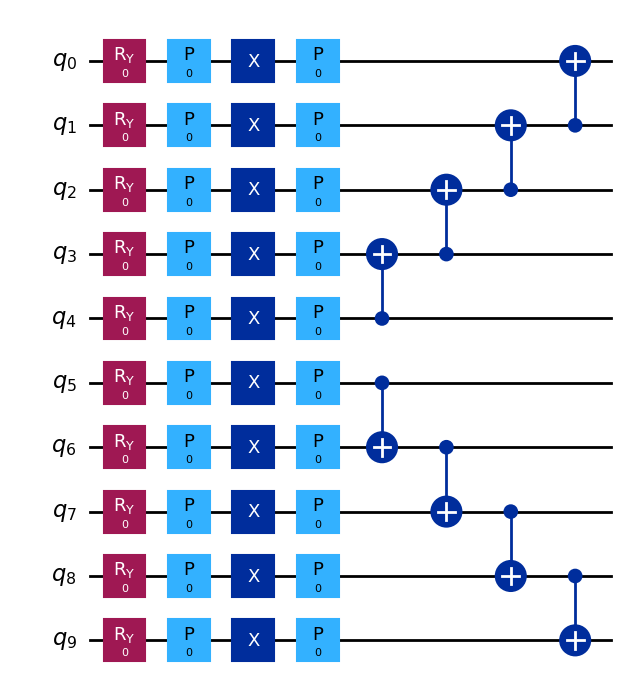

In [24]:
circuit = X_feature_Map([0] * 30)

circuit.draw("mpl")